In [1]:
import numpy as np
import matplotlib.pyplot as plt 


In [2]:
import pandas as pd
import glob

In [3]:
#uses data from https://zenodo.org/records/19051216
# be sure to cite both SphereX paper and the SPIFF paper
#
# spiff at https://arxiv.org/html/2604.22012v1#S4
#
# also should check IPAC to see what other acknowledgements are needed.  
# 
# but this is just preliminary work in progress

In [4]:
#test
spiff_dir = '/Users/gizis/data/SPIFF/known_bds/csv/' 
name='2MASS_J12074836-3900043_moca_oid_7523_spt_L1_spherex_spectrum.csv'
testname = spiff_dir + name
testname


'/Users/gizis/data/SPIFF/known_bds/csv/2MASS_J12074836-3900043_moca_oid_7523_spt_L1_spherex_spectrum.csv'

In [5]:
# Read the CSV file
df = pd.read_csv(testname)

# View the first few rows
print(df.head())

   wavelength_um  flux_flambda_w_m2_um    flux_error
0       0.744000          3.396870e-16  1.056324e-16
1       0.765882          2.632489e-16  6.505889e-17
2       0.787765          1.405044e-16  5.415963e-17
3       0.809647          4.027604e-16  8.849623e-17
4       0.831529          4.899962e-16  6.429802e-17


In [6]:
#using Gemini AI to get advice even though I used to be able to figure this out myself with StackExchange and documentation
#
# Note that missing data points are turned into NaN. (Presumably they were NaN to start with and that's why they are missing!)  
#
# Some data exploration below and looking at the Zenodo 

In [7]:
n1 = spiff_dir+'SDSS_J120020.66340615.4_moca_oid_370493_spt_L1_spherex_spectrum.csv'
n2 = spiff_dir+'WISEPC_J134806.99660327.8_moca_oid_370822_spt_L9_spherex_spectrum.csv'
df1 = pd.read_csv(n1)
df2=pd.read_csv(n2)
#above is just to test a couple. no longer used

In [8]:
# 1. Get all your file paths
#
# to include only the spectroscopically confirmed known brown dwarfs:
#file_paths = glob.glob('/Users/gizis/data/SPIFF/known_bds/csv/*.csv')
# this version also includes the previously know only by photometry:
#   possibly these are lower quality !?!?
file_paths = glob.glob('/Users/gizis/data/SPIFF/*known*/csv/*.csv')

data_list = []

for f in file_paths:
    # Read only the first two columns (index 0 and 1)
    # 
    df = pd.read_csv(f, usecols=['wavelength_um', 'flux_flambda_w_m2_um'])
    
    # 2. Set 'x' as the index
    # This is the "key" that Pandas uses to align different files
    df.set_index('wavelength_um', inplace=True)
    
    # 3. Rename the 'y' column to the filename 
    # This prevents column name collisions during the merge
    df.columns = [f]
    
    data_list.append(df)

# 4. Concatenate side-by-side (axis=1)
# Pandas looks at the 'x' index and lines everything up.
# Missing x-values in any file will result in a NaN for that file.
combined_df = pd.concat(data_list, axis=1)

# 5. Sort the index 
# This ensures your columns (x-values) are in order (e.g., 1, 2, 3...)
combined_df.sort_index(inplace=True)

# 6. Transpose and convert to NumPy
# Now: Rows = Files, Columns = x-values
final_array = combined_df.T.to_numpy()

print(f"Array Shape: {final_array.shape}") # (Number of files, Number of unique x points)

Array Shape: (10473, 102)


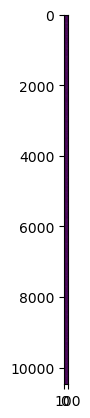

In [9]:
plt.imshow(final_array)

In [10]:
print(np.isnan(final_array).sum())


24173


In [11]:
combined_df.index

Index([             0.744, 0.7658823562509873, 0.7877647125019747,
        0.809647068752962, 0.8315294250039493, 0.8534117812549367,
       0.8752941375059239, 0.8971764937569112, 0.9190588500078986,
        0.940941206258886,
       ...
        4.654941222246955,   4.68964708552641, 4.7243529488058655,
         4.75905881208532,  4.793764675364775,   4.82847053864423,
        4.863176401923685, 4.8978822652031395,  4.932588128482594,
        4.967293991762049],
      dtype='float64', name='wavelength_um', length=102)

In [12]:
print("Filenames:", combined_df.columns.tolist())
filenames=combined_df.columns.tolist()

Filenames: ['/Users/gizis/data/SPIFF/known_bds/csv/ULAS_J011151.89-010534.2_moca_oid_369154_spt_L3.5_spherex_spectrum.csv', '/Users/gizis/data/SPIFF/known_bds/csv/SDSS_J103428.24414000.7_moca_oid_370266_spt_L0_spherex_spectrum.csv', '/Users/gizis/data/SPIFF/known_bds/csv/SDSS_J135327.06650944.5_moca_oid_370833_spt_L0_spherex_spectrum.csv', '/Users/gizis/data/SPIFF/known_bds/csv/WISEA_J035843.03103939.5_moca_oid_574254_spt_L3_spherex_spectrum.csv', '/Users/gizis/data/SPIFF/known_bds/csv/SDSS_J040100.96-060933.0_moca_oid_369529_spt_L4_spherex_spectrum.csv', '/Users/gizis/data/SPIFF/known_bds/csv/CWISE_J130440.45281927.7_moca_oid_572562_spt_dsdL9_spherex_spectrum.csv', '/Users/gizis/data/SPIFF/known_bds/csv/SDSS_J143132.79351300.6_moca_oid_370934_spt_L1_spherex_spectrum.csv', '/Users/gizis/data/SPIFF/known_bds/csv/ULAS_J085559.77003048.3_moca_oid_370012_spt_L3.5_spherex_spectrum.csv', '/Users/gizis/data/SPIFF/known_bds/csv/SDSS_J085359.10223335.8_moca_oid_370006_spt_L2_spherex_spectrum.cs

In [13]:
x_values = combined_df.index.to_numpy()
print(x_values)

[0.744      0.76588236 0.78776471 0.80964707 0.83152943 0.85341178
 0.87529414 0.89717649 0.91905885 0.94094121 0.96282356 0.98470592
 1.00658828 1.02847063 1.05035299 1.07223534 1.0941177  1.09899998
 1.13147057 1.16394116 1.19641175 1.22888234 1.26135293 1.29382352
 1.32629411 1.3587647  1.3912353  1.42370589 1.45617648 1.48864707
 1.52111766 1.55358825 1.58605884 1.61852943 1.63600004 1.68217651
 1.72835297 1.77452944 1.82070591 1.86688238 1.91305885 1.95923532
 2.00541179 2.05158825 2.09776472 2.14394119 2.19011766 2.23629413
 2.2824706  2.32864707 2.37482354 2.4230001  2.50529421 2.58758832
 2.66988244 2.75217655 2.83447066 2.91676478 2.99905889 3.08135301
 3.16364712 3.24594123 3.32823535 3.41052946 3.49282357 3.57511769
 3.6574118  3.73970591 3.80900002 3.8449412  3.88088238 3.91682356
 3.95276474 3.98870592 4.0246471  4.06058828 4.09652946 4.13247064
 4.16841182 4.204353   4.24029418 4.27623536 4.31217654 4.34811772
 4.3840589  4.41200018 4.44670604 4.48141191 4.51611777 4.5508

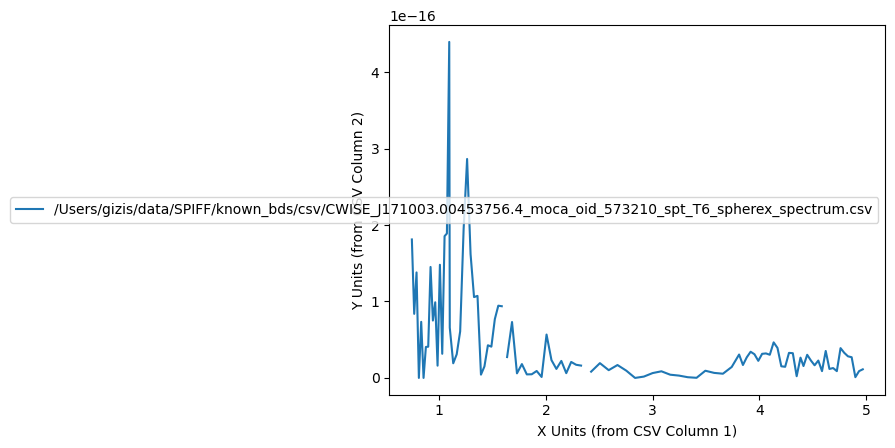

In [14]:
plt.plot(x_values, final_array[607], label=filenames[607]) 
plt.xlabel("X Units (from CSV Column 1)")
plt.ylabel("Y Units (from CSV Column 2)")
plt.legend()
plt.show()

In [15]:
import re

# Example filename from your list
filename = '/Users/gizis/data/SPIFF/known_bds/csv/2MASS_J112726481234310_moca_oid_1576818_spt_L4.0_spherex_spectrum.csv'

# This pattern looks for 'moca_oid_' and captures all digits (\d+) following it
match = re.search(r'moca_oid_(\d+)', filename)

if match:
    oid = match.group(1)
    print(f"Extracted OID: {oid}")

Extracted OID: 1576818


In [16]:
# Extract the numbers using list comprehension
oid_list = [re.search(r'moca_oid_(\d+)', f).group(1) for f in filenames if 'moca_oid_' in f]

print(oid_list)
# Output: ['1576818', '9988776']

['369154', '370266', '370833', '574254', '369529', '572562', '370934', '370012', '370006', '371544', '1576818', '571508', '7870', '369993', '571257', '371214', '168899', '369785', '371844', '370814', '245315', '369075', '1585525', '1539130', '370261', '369949', '369841', '371551', '369633', '15691', '4510555', '1569025', '571549', '369295', '370787', '4808255', '370346', '6677', '371522', '371269', '1711463', '370380', '370830', '370786', '4324064', '371454', '371150', '1711369', '370659', '370106', '1563172', '369260', '370492', '370953', '629991', '325', '371289', '4324266', '369998', '10816', '10649', '371085', '573244', '571840', '370326', '369788', '370845', '369800', '1565629', '369796', '369262', '371011', '10420', '371727', '370572', '369752', '572806', '573171', '371643', '1498', '1711315', '1711312', '571573', '571606', '369088', '371913', '370144', '1569477', '371018', '369303', '371335', '371070', '369911', '371060', '371103', '280882', '1552373', '371023', '573780', '37031

In [17]:
table1 = pd.read_csv('/Users/gizis/data/SPIFF/spiff_tables/data_spherex_spectra_spiff_fulltable.csv')
# this table doesn't seem to have any of the actual data. so this is worthless. it just has header

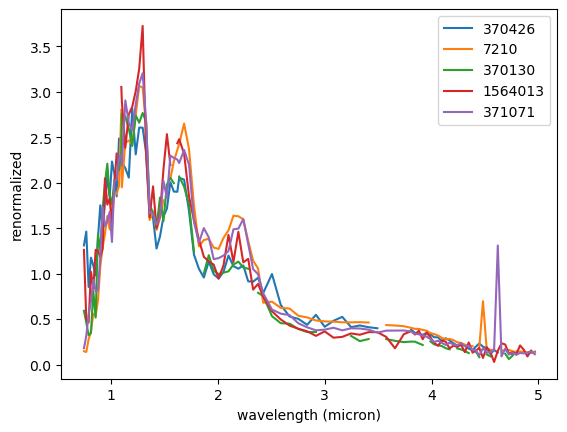

In [18]:
plt.plot(x_values, final_array[100]/np.nanmean(final_array[100]),label=oid_list[100]) 
plt.plot(x_values, final_array[101]/np.nanmean(final_array[101]),label=oid_list[101]) 
plt.plot(x_values, final_array[102]/np.nanmean(final_array[102]),label=oid_list[102]) 
plt.plot(x_values, final_array[103]/np.nanmean(final_array[103]),label=oid_list[103]) 
plt.plot(x_values, final_array[104]/np.nanmean(final_array[104]),label=oid_list[104]) 
plt.xlabel('wavelength (micron)')
plt.ylabel("renormalized")
plt.legend()
plt.show()

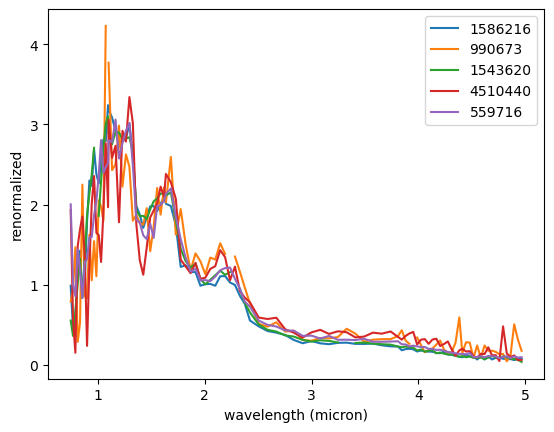

In [19]:
plt.plot(x_values, final_array[9100]/np.nanmean(final_array[9100]),label=oid_list[9100]) 
plt.plot(x_values, final_array[9101]/np.nanmean(final_array[9101]),label=oid_list[9101]) 
plt.plot(x_values, final_array[9102]/np.nanmean(final_array[9102]),label=oid_list[9102]) 
plt.plot(x_values, final_array[9103]/np.nanmean(final_array[9103]),label=oid_list[9103]) 
plt.plot(x_values, final_array[9104]/np.nanmean(final_array[9104]),label=oid_list[9104]) 
plt.xlabel('wavelength (micron)')
plt.ylabel("renormalized")
plt.legend()
plt.show()
# plot some high numbers which should be the photometric ones.

In [20]:
combined_df.to_pickle('spiff_all.pkl')

# To load it back later:
# combined_df = pd.read_pickle('spiff_all.pkl')